# Optimizing ESI Parameters within the Pareto Frontier

<span style="color: purple;">**This notebook has been tested with `spatialize v1.2.0`**</span>

The classic method for optimizing ESI parameters minimizes the cross-validation prediction error (see the [esi_hparams_search notebook](./esi_hparams_search.ipynb)).
This notebook introduces an alternative method where the *encoder error*, related to the partitioning process, and the *decoder error*, related to the local interpolation, are analyzed separately.  


## Encoder Error VS Decoder Error

In ESI interpolation, error can originate form two different sources:

**Encoder Error**
: In ESI, the space partitioning process acts as the *encoder*, where each unique space partition induces a specific space structure. The encoder error is a measure of how well a space partition reflects local stationarity. A low encoder error indicates that most points that fall on the same cell have a similar distribution.

**Decoder Error**
: In ESI, the local interpolator acts as the *decoder*, producing estimates using the samples from the cell where a target location falls into. The decoder error measures the accuracy of the local interpolation function. A low decoder error indicates robust predictions.

> A finer partition will result in the use of smaller but more homogeneous samples for local interpolation. This decreases the encoder error, but will also provide less information to the local interpolator, thus increasing the decoder error.

## The esi pareto parameter search function

The `esi_pareto_hparams_search` function receives sets of candidate values for both encoder and decoder parameters. It then computes encoder and encoder errors for each combination, identifying the *pareto frontier*, i.e. the set of optimal, trade-off solutions.

This function receives the same `points`, `values` and `seed` inputs as most ESI methods, as well as ESI arguments, parameter search arguments, plus function-specific arguments for both the decoder (cross-validation) and encoder (robustness bound) computations:

**ESI Arguments**

- `n_partitions : list of int`, default = [100, 200, 300]

    Number of distinct partitions—spatial configurations—used for ESI.

- `p_process : str`, default = 'mondrian'

    Partitioning method used for ESI ('mondrian' or 'voronoi'). Only 'mondrian' is supported for the encoder error ε̂ (Algorithm 1 is Mondrian-only); a non-Mondrian `p_process` only affects the decoder (CV) step and triggers a warning.

- `local_interpolator : str`, default = 'idw'

    Interpolator applied within each local partition element ('idw', 'adaptive_idw' or 'kriging').

- `seed : int`, default = np.random.randint(1000, 10000)

    Random seed shared by both the encoder and decoder steps.


**Function Specific Arguments — Decoder (cross-validation)**

- `k : int`, default = 5

    Determines k for the k-fold method. Using -1 or "loo" implements the leave-one-out method.

- `scoring : func`, default = spatialize.gs.esi.scorefunction.neg_log_likelihood

    Scoring function used to evaluate the decoder error R_CV. Functions included in the scorefunction module are: mae, mse, rmse, neg_log_likelihood and crps. If a distribution-based scorer (neg_log_likelihood or crps) is combined with an `n_partitions` value below 30, it is silently replaced with mae and a warning is raised.

- `folding_seed : int`, default = np.random.randint(1000, 10000)

    Sets random state for the k-fold assignment.

**Function Specific Arguments — Encoder (robustness bound)**

- `pair_strategy : str`, default = 'max_min'

    Point-pairing strategy used when sweeping partition cells to accumulate the KL-based robustness bound. 'max_min' pairs the highest- and lowest-mean points in a cell; 'exhaustive' evaluates all ordered pairs.

- `point_model_name : str`, default = 'kde'

    Density model used to estimate each point's predictive distribution for the KL computation. Alternatives are 'kde', 'emm' and 'vim'.

- `nan_model_name : str`, default = 'ignore'

    Strategy for handling NaNs in ESI samples before density fitting. Alternatives are 'ignore' and 'replace'.

- `support_sample_size : int`, default = 500

    Number of points in the shared grid used to numerically integrate the KL divergence.

**Search Parameters**

- Related to the ESI implementation:

    - `alpha : list of float`, default = list(np.flip(np.arange(0.70, 0.90, 0.05)))

        Controls how coarse or fine each partition is. Accepted range is [0, 1], where 0 will generate the coarsest partition and 1 the finest. Recommended range is [0.7, 0.95]. High values may lead to extended processing times and high memory usage.

- Base Interpolator Specific Arguments for 'idw':

    - `exponent : list of float`, default = list(np.arange(1.0, 5.0, 1.0))

        The exponent controls point weighting. As its value increases, samples located farther away lose weight, while nearest points gain importance. High values may result in NaN values in the output.

- Base Interpolator Specific Arguments for 'kriging':

    - `model : list of str`, default = ["spherical", "exponential"]

        Mathematical model for the isotropic covariance function. Alternatives are “spherical”, “exponential”, “cubic” and “gaussian”.

    - `nugget : list of float`, default = [0.0, 0.5]

        Data variance on a very small scale or a very small neighborhood.

    - `range : list of float`, default = [50.0, 200.0]

        Data spatial separation on which variance stabilizes.

    - `sill : list of float`, default = [0.9, 1.0]

        Represents the total variance of the data

- Base Interpolator Specific Arguments for 'adaptiveidw':

    - `metric : list of str`, default = ["mae"]

        Metric used for the per-cell LOO parameter optimization.

    - `parallelize : bool`, default = False

        Whether to parallelize the per-cell parameter search.

## Usage Example
We will now examine a full usage example.

In [1]:
# Libraries
import sys
sys.path.append('../')
from utils import SyntheticScenario

import numpy as np
import matplotlib.pyplot as plt

from spatialize.gs.esi import (
    esi_pareto_hparams_search,
    esi_nongriddata)

from spatialize.viz import PlotStyle, plot_nongriddata
import spatialize.gs.esi.scorefunction as sf

First, let us consider a synthetic data scenario.

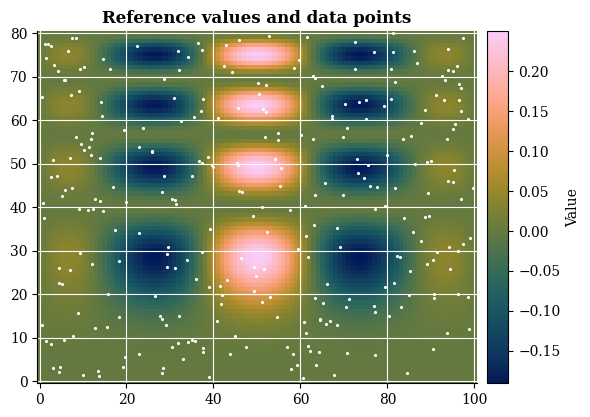

In [2]:
scenario = SyntheticScenario(n_dims=2, extent=[0, 100, 0, 80], griddata=False)
points, values, xi, reference_values = scenario.simulate_scenario(n_samples=300, seed=42)

# Visualize reference values and samples
scenario.plot_2d_scenario(points, xi, reference_values,
                          theme='publication', cmap='batlow', figsize=(6, 5))
plt.tight_layout()
plt.show()

# for result plots:
vmin, vmax = reference_values.min(), reference_values.max()

### 1 — `esi_pareto_hparams_search` run

In [3]:
# Finding the pareto frontier
pareto_result = esi_pareto_hparams_search(
    points, values,
    local_interpolator="idw",
    n_partitions=[200, 400],
    alpha=[0.80, 0.85, 0.9],
    exponent=[0.5, 1.0, 2.0],
    scoring=sf.neg_log_likelihood,
    k=5,
    pair_strategy="max_min",
    point_model_name="kde",
    seed=0,
)

finished 100% of 18 iterations ... 

done (elapsed time: 24s)


Here, the `pareto_result` variable contains an `ESIParetoResult` object. This objecy stores the metrics for each evaluated scenario within the `all_results` attribute, and the combinations that fall in the pareto frontier are stored in the `frontier` attribute.

In [4]:
# Inspect the pareto frontier
print(f"Configs evaluated : {len(pareto_result.all_results)}")
print(f"Pareto frontier   : {len(pareto_result.frontier)}")

for r in pareto_result.frontier:
    p = r["params"]
    print(f"  T={p['n_partitions']:3d}  α={p['alpha']}  exp={p['exponent']}  "
          f"encoder_error={r['epsilon']:.4f}  decoder_error={r['decoder_error']:.4f}")

Configs evaluated : 18
Pareto frontier   : 7
  T=200  α=0.8  exp=0.5  encoder_error=0.0160  decoder_error=-0.0549
  T=200  α=0.8  exp=1.0  encoder_error=0.0186  decoder_error=-0.0570
  T=200  α=0.85  exp=0.5  encoder_error=0.0143  decoder_error=-0.0518
  T=400  α=0.8  exp=0.5  encoder_error=0.0227  decoder_error=-0.1785
  T=400  α=0.8  exp=1.0  encoder_error=0.0290  decoder_error=-0.1810
  T=400  α=0.8  exp=2.0  encoder_error=0.0342  decoder_error=-0.1817
  T=400  α=0.9  exp=1.0  encoder_error=0.0217  decoder_error=-0.1676


### 2 — Strategies for choosing a parameter combination within the frontier

Frequently, more than one combination will fall within the frontier.
The `ESIParetoResult.best_result()` method offers four different strategies to select the best combination for each specific application.

- `"min_decoder"` *(default)*

    Selects the frontier point with the lowest decoder error. Use this when prediction accuracy is the priority and some risk of non-stationary, less-robust partitions is acceptable.

- `"min_epsilon"`

    Selects the frontier point with the lowest encoder error ε̂. Use this when robustness to non-stationarity is the priority, even if it costs some prediction accuracy.

- `"knee"`

    Selects the geometric *knee* of the frontier: the point with maximum perpendicular distance from the line connecting the two extreme frontier points (in normalized objective space). This represents the most balanced trade-off between encoder and decoder error — the point where improving one objective further would cost the most in the other.

- `"utopia"`

    Selects the frontier point closest to the *utopia* point — the (generally infeasible) vector formed by the best encoder error and the best decoder error found anywhere in the frontier, taken independently — in normalized objective space.

When the frontier contains a single point, the strategy is irrelevant and that point is returned directly.


The dict returned by `best_result()` is designed to be passed directly to `esi_griddata` / `esi_nongriddata` through the `best_params_found` argument.
> Note: **n_partitions must be passed manually** since its overwritten at call.

In [5]:
# auxiliary plotting function

def plot_result(esi_result):
    with PlotStyle(theme='publication', cmap='batlow', precision_cmap='cork') as style:
        fig = plt.figure(figsize=(10,8))
        gs = fig.add_gridspec(1, 2, wspace=0.45)
        ax1, ax2 = gs.subplots()

        ax1.set_title('Estimation')
        plot_nongriddata(esi_result._estimation, xi_locations=xi, ax=ax1, cmap = style.cmap, vmin=reference_values.min(), vmax=reference_values.max())
        ax1.set_aspect('equal')

        error = esi_result._estimation-reference_values
        absmax = np.max(np.abs(error))
        ax2.set_title('Error')
        plot_nongriddata(error, xi_locations=xi, ax=ax2, cmap=style.precision_cmap, vmin = -absmax, vmax= absmax)
        ax2.set_aspect('equal')
    
    plt.show()

#### min_decoder strategy

Selected config: T=400  α=0.8  exp=2.0
finished 100% of 400 iterations ... 

done (elapsed time:  3s)


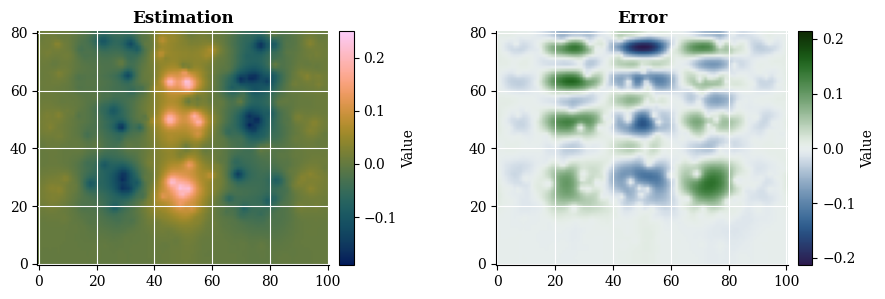

In [6]:
best_min_decoder = pareto_result.best_result(strategy="min_decoder")
T_md, a_md, exp_md = best_min_decoder['n_partitions'], best_min_decoder['alpha'], best_min_decoder['exponent']
print(f"Selected config: T={T_md}  α={a_md}  exp={exp_md}")

esi_result_decoder = esi_nongriddata(
    points, values, xi,
    n_partitions=best_min_decoder['n_partitions'],      # manually pass n_partitions from the best config
    best_params_found=best_min_decoder     # optimized parameters
)

plot_result(esi_result_decoder)

#### min_epsilon strategy

Selected config: T=200  α=0.85  exp=0.5
finished 100% of 200 iterations ... 

done (elapsed time:  1s)


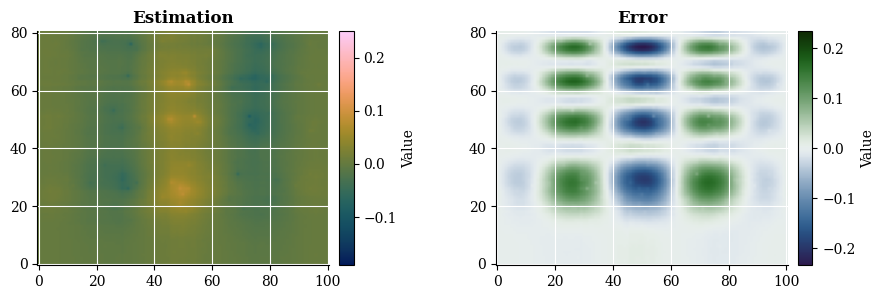

In [7]:
best_min_encoder = pareto_result.best_result(strategy="min_epsilon")
T_md, a_md, exp_md = best_min_encoder['n_partitions'], best_min_encoder['alpha'], best_min_encoder['exponent']
print(f"Selected config: T={T_md}  α={a_md}  exp={exp_md}")

esi_result_encoder = esi_nongriddata(
    points, values, xi,
    n_partitions=best_min_encoder['n_partitions'],      # manually pass n_partitions from the best config
    best_params_found=best_min_encoder     # optimized parameters
)

plot_result(esi_result_encoder)

#### knee strategy

Knee config: T=400  α=0.8  exp=0.5
finished 100% of 400 iterations ... 

done (elapsed time:  3s)


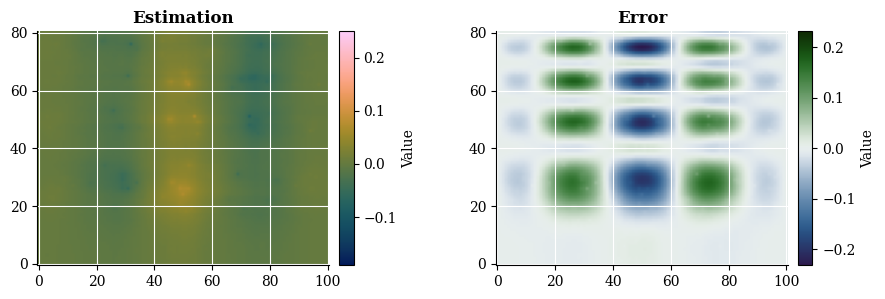

In [8]:
best_knee = pareto_result.best_result(strategy="knee")
T_kn, a_kn, exp_kn = best_knee['n_partitions'], best_knee['alpha'], best_knee['exponent']
print(f"Knee config: T={T_kn}  α={a_kn}  exp={exp_kn}")

esi_result_knee = esi_nongriddata(
    points, values, xi,
    n_partitions=best_knee['n_partitions'],      # manually pass n_partitions from the best config
    best_params_found=best_knee     # optimized parameters
)

plot_result(esi_result_knee)

#### utopia strategy

Utopia config: T=400  α=0.9  exp=1.0
finished 100% of 400 iterations ... 

done (elapsed time:  2s)


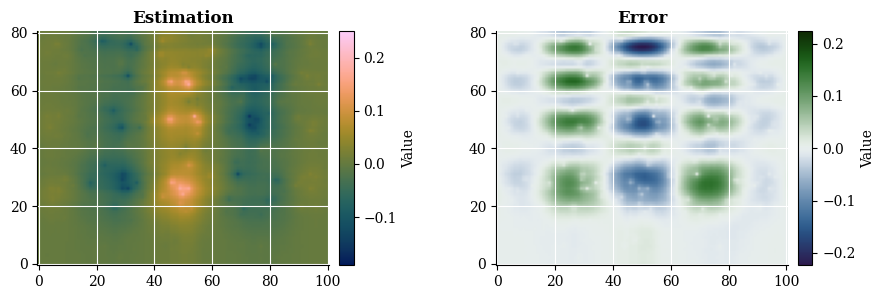

In [9]:
best_utopia = pareto_result.best_result(strategy="utopia")
print(f"Utopia config: T={best_utopia['n_partitions']}  α={best_utopia['alpha']}  exp={best_utopia['exponent']}")

esi_result_utopia = esi_nongriddata(
    points, values, xi,
    n_partitions=best_utopia['n_partitions'],      # manually pass n_partitions from the best config
    best_params_found=best_utopia     # optimized parameters
)

plot_result(esi_result_utopia)

### 3 — Pareto plot

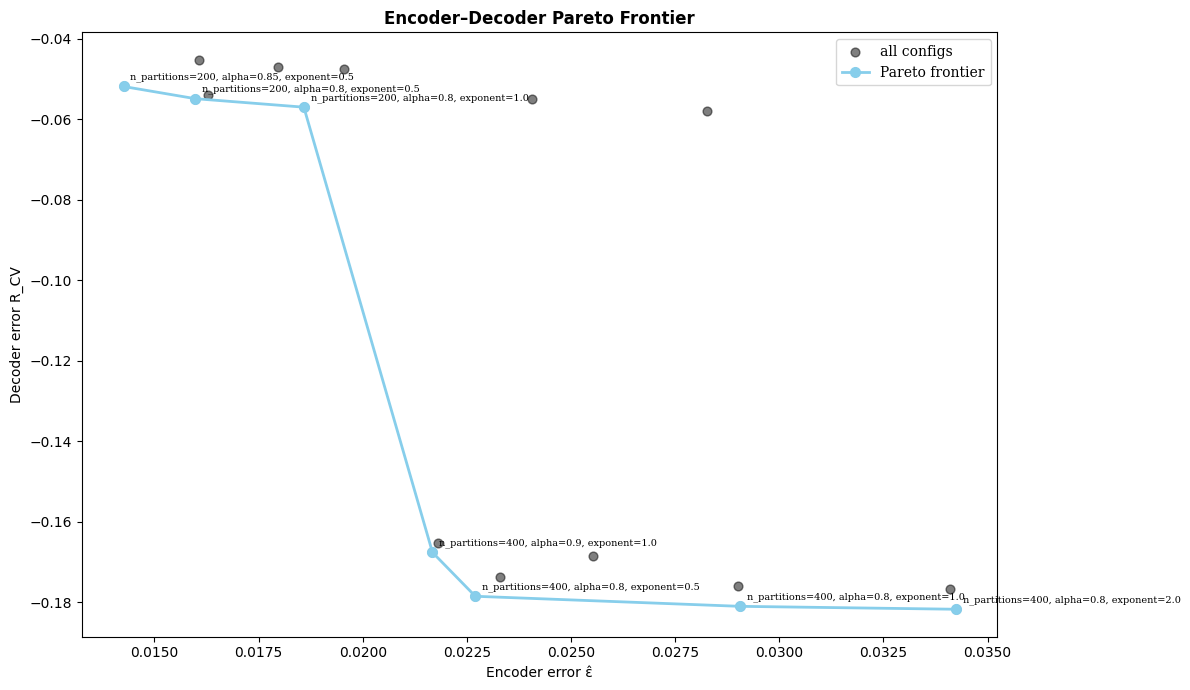

In [10]:
fig, ax = plt.subplots(figsize=(12, 7))

pareto_result.plot(annotate=True, theme='publication', frontier_color='skyblue', ax=ax)
plt.show()

## Example 2: Adaptive ESI

Adaptive ESI does not have global decoder parameters, so the trade-off lies only in the effects of the encoder parameters (alpha and n_partitions).

In [15]:
adaptive_pareto_result = esi_pareto_hparams_search(
    points, values,
    local_interpolator="adaptiveidw",
    n_partitions=[100, 200],
    alpha=[0.80, 0.85, 0.9],
    scoring=sf.mae,
    parallelize=True,
    k=5,
    pair_strategy="max_min",
    point_model_name="kde",
    seed=0
)

finished 100% of 6 iterations ... 

done (elapsed time:  1m  5s)


In [16]:
# Visualize the frontier
for r in adaptive_pareto_result.frontier:
    p = r["params"]
    print(f"  T={p['n_partitions']:3d}  α={p['alpha']}  "
          f"encoder_error={r['epsilon']:.6f}  decoder_error={r['decoder_error']:.6f}")

  T=100  α=0.9  encoder_error=0.016537  decoder_error=0.014566
  T=200  α=0.9  encoder_error=0.025622  decoder_error=0.014530


Since we only have two results in the frontier, and both have the same decoder error, we'll use the `min_epsilon` strategy:

finished 100% of 100 iterations ... 

done (elapsed time:  2s)
finished 100% of 100 iterations ... 

done (elapsed time:  0s)


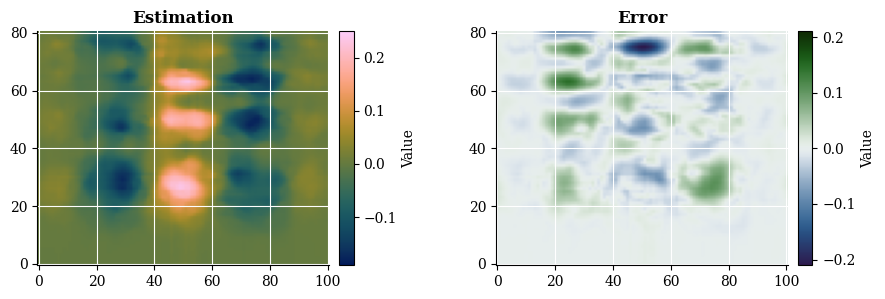

In [17]:
best = adaptive_pareto_result.best_result(strategy="min_epsilon")

adaptive_esi_result_encoder = esi_nongriddata(
    points, values, xi,
    local_interpolator='adaptiveidw',
    parallelize=True,
    n_partitions=best['n_partitions'],      # manually pass n_partitions from the best config
    best_params_found=best    # optimized parameters
)

plot_result(adaptive_esi_result_encoder)

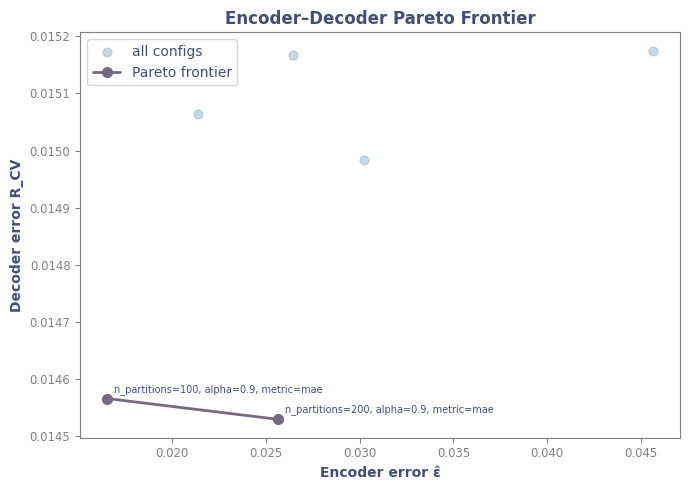

In [18]:
adaptive_pareto_result.plot(annotate=True)
plt.show()